# 02 Beta系数估计

## 2.1 目的与说明

本notebook完成以下任务：

1. **全样本Beta估计**: 基于CAPM超额收益模型，使用OLS回归估计每只股票的全样本Beta系数

2. **分年度Beta估计**: 按自然年度分组，估计各年度的Beta系数，分析Beta的时变特征

3. **滚动Beta估计**: 使用60个交易日滚动窗口，估计滚动Beta系数，分析Beta的动态演变

4. **残差诊断**: 对回归残差进行Ljung-Box自相关检验和White异方差检验

**CAPM模型**: 
$$r_{i,t} - r_f = \alpha_i + \beta_i (r_{m,t} - r_f) + \varepsilon_{i,t}$$

其中 $r_f = 0.025 / 252$ 为日无风险利率

In [21]:
# 导入必要的库
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white
from tqdm import tqdm
import warnings
import os
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
import seaborn as sns
from scipy import stats

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置路径（使用相对路径）
DATA_CLEAN = os.path.join('data_clean')
OUTPUT_Q2 = os.path.join('output', 'Q2_beta')
OUTPUT_Q3 = os.path.join('output', 'Q3_yearly_beta')
OUTPUT_Q4 = os.path.join('output', 'Q4_rolling_beta')

for dir_path in [OUTPUT_Q2, OUTPUT_Q3, OUTPUT_Q4]:
    os.makedirs(dir_path, exist_ok=True)

# 无风险利率（日频）
RF_DAILY = 0.025 / 252

print('库导入成功，无风险利率: {:.6f}'.format(RF_DAILY))

库导入成功，无风险利率: 0.000099


**结果解读**: 本代码导入了CAPM回归和Beta估计所需的库，包括pandas/numpy数据处理、statsmodels统计建模、seaborn可视化等。无风险利率设置为年化2.5%（日频约0.000099），用于计算超额收益。

In [22]:
# 加载清洗后的收益率数据
returns = pd.read_csv(os.path.join(DATA_CLEAN, 'returns.csv'), index_col=0, parse_dates=True)
prices = pd.read_csv(os.path.join(DATA_CLEAN, 'prices.csv'), index_col=0, parse_dates=True)

print('数据加载成功！')
print(f'数据范围: {returns.index.min()} 至 {returns.index.max()}')
print(f'数据维度: {returns.shape}')
print(f'\n列名: {returns.columns.tolist()}')

数据加载成功！
数据范围: 2019-01-03 00:00:00 至 2026-03-25 00:00:00
数据维度: (1739, 6)

列名: ['ICBC', 'YILI', 'ZTE', 'YUNNAN', 'SINOPEC', 'CSI300']


**结果解读**: 本代码从data_clean目录加载清洗后的收益率数据，包含5只股票和沪深300指数共6个资产的1739个观测值，时间范围从2019年1月3日至2026年3月25日。

In [23]:
# 计算超额收益
excess_returns = returns.copy()
for col in returns.columns:
    excess_returns[col] = returns[col] - RF_DAILY

print('超额收益计算完成！')
print('\n各资产平均超额收益率:')
print((excess_returns.mean() * 252).round(4))

超额收益计算完成！

各资产平均超额收益率:
ICBC       0.0393
YILI       0.0279
ZTE        0.0636
YUNNAN     0.0196
SINOPEC    0.0237
CSI300     0.0403
dtype: float64


**结果解读**: 本代码通过将各资产收益率减去无风险利率日值来计算超额收益，超额收益反映承担风险获得的额外回报（风险溢价）。科技股ZTE年化超额收益最高（6.36%），医药股YUNNAN最低（1.96%）。

## 2.3 全样本Beta系数估计

In [24]:
# 定义CAPM回归函数
def capm_regression(stock_excess, market_excess):
    """
    进行CAPM回归分析
    r_i - r_f = alpha + beta * (r_m - r_f) + epsilon
    """
    # 添加常数项
    X = sm.add_constant(market_excess)
    y = stock_excess
    
    # OLS回归
    model = sm.OLS(y, X).fit()
    
    return model

# 对每只股票进行CAPM回归
stock_names = ['ICBC', 'YILI', 'ZTE', 'YUNNAN', 'SINOPEC']
market_excess = excess_returns['CSI300']

full_sample_results = []

print('='*100)
print('全样本CAPM回归结果')
print('='*100)

for stock in stock_names:
    stock_excess = excess_returns[stock]
    model = capm_regression(stock_excess, market_excess)
    
    # 提取回归结果
    result = {
        'Stock': stock,
        'Alpha': model.params['const'],
        'Alpha_pval': model.pvalues['const'],
        'Beta': model.params['CSI300'],
        'Beta_pval': model.pvalues['CSI300'],
        'R-squared': model.rsquared,
        'Adj_R2': model.rsquared_adj,
        'Std_Error': model.resid.std(),
        'F_stat': model.fvalue,
        'F_pval': model.f_pvalue,
        'N_obs': int(model.nobs)
    }
    full_sample_results.append(result)
    
    print(f'\n{stock}:')
    print(f'  Alpha = {result["Alpha"]:.6f} (p-value = {result["Alpha_pval"]:.4f})')
    print(f'  Beta  = {result["Beta"]:.4f} (p-value = {result["Beta_pval"]:.4f})')
    print(f'  R²    = {result["R-squared"]:.4f}')
    print(f'  残差标准误 = {result["Std_Error"]:.6f}')

全样本CAPM回归结果

ICBC:
  Alpha = 0.000127 (p-value = 0.3889)
  Beta  = 0.1807 (p-value = 0.0000)
  R²    = 0.1100
  残差标准误 = 0.006152

YILI:
  Alpha = -0.000015 (p-value = 0.9589)
  Beta  = 0.7853 (p-value = 0.0000)
  R²    = 0.3870
  残差标准误 = 0.011827

ZTE:
  Alpha = 0.000060 (p-value = 0.9074)
  Beta  = 1.2047 (p-value = 0.0000)
  R²    = 0.3124
  残差标准误 = 0.021386

YUNNAN:
  Alpha = -0.000036 (p-value = 0.9084)
  Beta  = 0.7112 (p-value = 0.0000)
  R²    = 0.2983
  残差标准误 = 0.013053

SINOPEC:
  Alpha = 0.000058 (p-value = 0.7455)
  Beta  = 0.2231 (p-value = 0.0000)
  R²    = 0.1130
  残差标准误 = 0.007477


**结果解读**: 本代码定义了capm_regression函数，实现CAPM模型的OLS回归估计（r_i - r_f = alpha + beta * (r_m - r_f) + epsilon），并对每只股票进行全样本回归。回归结果包括Alpha、Beta、R-squared等统计量。

In [25]:
# 汇总为表格
full_sample_df = pd.DataFrame(full_sample_results)

# 添加显著性标记
def significance_stars(pval):
    if pval < 0.001:
        return '***'
    elif pval < 0.01:
        return '**'
    elif pval < 0.05:
        return '*'
    else:
        return ''

full_sample_df['Alpha_sig'] = full_sample_df['Alpha_pval'].apply(significance_stars)
full_sample_df['Beta_sig'] = full_sample_df['Beta_pval'].apply(significance_stars)

# 格式化显示
display_df = full_sample_df[['Stock', 'Alpha', 'Alpha_sig', 'Beta', 'Beta_sig', 'R-squared', 'Std_Error', 'N_obs']].copy()
display_df.columns = ['股票', 'Alpha', '', 'Beta', '', 'R²', '残差标准误', '观测数']

print('='*100)
print('全样本CAPM回归结果汇总表')
print('='*100)
print(display_df.round(6).to_string(index=False))
print('\n注: *** p<0.001, ** p<0.01, * p<0.05')

全样本CAPM回归结果汇总表
     股票     Alpha      Beta           R²    残差标准误  观测数
   ICBC  0.000127  0.180696 *** 0.109950 0.006152 1739
   YILI -0.000015  0.785285 *** 0.386970 0.011827 1739
    ZTE  0.000060  1.204722 *** 0.312420 0.021386 1739
 YUNNAN -0.000036  0.711187 *** 0.298262 0.013053 1739
SINOPEC  0.000058  0.223074 *** 0.113029 0.007477 1739

注: *** p<0.001, ** p<0.01, * p<0.05


**结果解读**: 本代码汇总全样本CAPM回归结果，生成包含Alpha、Beta、R-squared及显著性标记的表格。B系数排序反映各股票市场敏感度；Alpha不显著说明个股难以获得超额收益。

In [26]:
# 保存全样本结果
full_sample_df.to_csv(os.path.join(OUTPUT_Q2, 'full_sample_beta.csv'), index=False)
print('全样本Beta结果已保存至 output/Q2_beta/full_sample_beta.csv')

全样本Beta结果已保存至 output/Q2_beta/full_sample_beta.csv


**结果解读**: 本代码保存全样本Beta估计结果至CSV文件，包含每只股票的Alpha、Beta、R²及显著性检验信息。

## 2.4 残差诊断

In [27]:
# 对每只股票的回归残差进行诊断检验
residual_diagnostics = []

print('='*100)
print('残差诊断检验结果')
print('='*100)

for stock in stock_names:
    stock_excess = excess_returns[stock]
    model = capm_regression(stock_excess, market_excess)
    residuals = model.resid
    
    # Ljung-Box自相关检验（滞后阶数10）
    lb_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_stat = lb_result['lb_stat'].values[0]
    lb_pval = lb_result['lb_pvalue'].values[0]
    
    # White异方差检验
    X = sm.add_constant(market_excess)
    white_result = het_white(residuals, X)
    white_stat = white_result[0]
    white_pval = white_result[1]
    
    diagnostic = {
        'Stock': stock,
        'LB_Stat': lb_stat,
        'LB_pval': lb_pval,
        'LB_Conclusion': 'Reject H0' if lb_pval < 0.05 else 'Not Reject H0',
        'White_Stat': white_stat,
        'White_pval': white_pval,
        'White_Conclusion': 'Reject H0' if white_pval < 0.05 else 'Not Reject H0'
    }
    residual_diagnostics.append(diagnostic)
    
    print(f'\n{stock}:')
    print(f'  Ljung-Box检验 (lag=10):')
    print(f'    统计量 = {lb_stat:.4f}, p-value = {lb_pval:.4f}')
    print(f'    结论: {diagnostic["LB_Conclusion"]} (存在自相关)' if lb_pval < 0.05 else f'    结论: {diagnostic["LB_Conclusion"]} (无自相关)')
    print(f'  White检验:')
    print(f'    统计量 = {white_stat:.4f}, p-value = {white_pval:.4f}')
    print(f'    结论: {diagnostic["White_Conclusion"]} (存在异方差)' if white_pval < 0.05 else f'    结论: {diagnostic["White_Conclusion"]} (无异方差)')

残差诊断检验结果

ICBC:
  Ljung-Box检验 (lag=10):
    统计量 = 14.0780, p-value = 0.1695
    结论: Not Reject H0 (无自相关)
  White检验:
    统计量 = 121.4222, p-value = 0.0000
    结论: Reject H0 (存在异方差)

YILI:
  Ljung-Box检验 (lag=10):
    统计量 = 17.9735, p-value = 0.0554
    结论: Not Reject H0 (无自相关)
  White检验:
    统计量 = 18.5229, p-value = 0.0001
    结论: Reject H0 (存在异方差)

ZTE:
  Ljung-Box检验 (lag=10):
    统计量 = 6.9760, p-value = 0.7277
    结论: Not Reject H0 (无自相关)
  White检验:
    统计量 = 1.3747, p-value = 0.5029
    结论: Not Reject H0 (无异方差)

YUNNAN:
  Ljung-Box检验 (lag=10):
    统计量 = 14.8059, p-value = 0.1393
    结论: Not Reject H0 (无自相关)
  White检验:
    统计量 = 4.7450, p-value = 0.0932
    结论: Not Reject H0 (无异方差)

SINOPEC:
  Ljung-Box检验 (lag=10):
    统计量 = 34.0077, p-value = 0.0002
    结论: Reject H0 (存在自相关)
  White检验:
    统计量 = 21.0817, p-value = 0.0000
    结论: Reject H0 (存在异方差)


**结果解读**: 本代码对每只股票CAPM回归的残差进行诊断检验：Ljung-Box自相关检验（检验残差是否存在序列相关）和White异方差检验（检验残差方差是否恒定）。

In [28]:
# 汇总残差诊断结果
diagnostics_df = pd.DataFrame(residual_diagnostics)
diagnostics_display = diagnostics_df[['Stock', 'LB_Stat', 'LB_pval', 'LB_Conclusion', 'White_Stat', 'White_pval', 'White_Conclusion']].copy()
diagnostics_display.columns = ['股票', 'LB统计量', 'LB_p值', 'LB结论', 'White统计量', 'White_p值', 'White结论']

print('\n' + '='*100)
print('残差诊断检验汇总表')
print('='*100)
print(diagnostics_display.round(4).to_string(index=False))
print('\n注: Ljung-Box检验H0为残差无自相关；White检验H0为残差同方差')


残差诊断检验汇总表
     股票   LB统计量  LB_p值          LB结论  White统计量  White_p值       White结论
   ICBC 14.0780 0.1695 Not Reject H0  121.4222    0.0000     Reject H0
   YILI 17.9735 0.0554 Not Reject H0   18.5229    0.0001     Reject H0
    ZTE  6.9760 0.7277 Not Reject H0    1.3747    0.5029 Not Reject H0
 YUNNAN 14.8059 0.1393 Not Reject H0    4.7450    0.0932 Not Reject H0
SINOPEC 34.0077 0.0002     Reject H0   21.0817    0.0000     Reject H0

注: Ljung-Box检验H0为残差无自相关；White检验H0为残差同方差


**结果解读**: 本代码汇总残差诊断检验结果。Ljung-Box检验H0为残差无自相关；White检验H0为残差同方差。结论显示SINOPEC同时存在自相关和异方差问题。

In [29]:
# 保存残差诊断结果
diagnostics_df.to_csv(os.path.join(OUTPUT_Q2, 'residual_diagnostics.csv'), index=False)
print('残差诊断结果已保存至 output/Q2_beta/residual_diagnostics.csv')

残差诊断结果已保存至 output/Q2_beta/residual_diagnostics.csv


**结果解读**: 本代码保存残差诊断检验结果。Ljung-Box检验和White检验结果将揭示CAPM模型是否存在设定偏误，指导后续模型的改进方向。

## 2.5 分年度Beta系数估计

In [30]:
# 添加年份列
returns_with_year = returns.copy()
returns_with_year['year'] = returns_with_year.index.year

excess_returns_with_year = excess_returns.copy()
excess_returns_with_year['year'] = excess_returns_with_year.index.year

# 获取年份列表
years = sorted(returns_with_year['year'].unique())
print(f'数据涵盖年份: {years}')

数据涵盖年份: [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


**结果解读**: 本代码为收益率数据添加年份标识字段，用于按年度分组分析。数据涵盖2019至2026年，其中2026年数据仅包含前三个月。

In [31]:
# 分年度估计Beta
yearly_beta_results = []

for year in years:
    year_data = excess_returns_with_year[excess_returns_with_year['year'] == year]
    market_excess_year = year_data['CSI300']
    
    for stock in stock_names:
        stock_excess_year = year_data[stock]
        
        # 确保有足够的数据点
        if len(stock_excess_year) < 30:
            continue
            
        model = capm_regression(stock_excess_year, market_excess_year)
        
        result = {
            'Year': year,
            'Stock': stock,
            'Alpha': model.params['const'],
            'Beta': model.params['CSI300'],
            'R-squared': model.rsquared,
            'N_obs': int(model.nobs)
        }
        yearly_beta_results.append(result)

yearly_beta_df = pd.DataFrame(yearly_beta_results)
print(f'分年度Beta估计完成，共 {len(yearly_beta_df)} 条记录')

分年度Beta估计完成，共 40 条记录


**结果解读**: 本代码按自然年度对每只股票分别进行CAPM回归，估计各年度的Beta系数。分年度Beta可揭示系统性风险的时变特征，共生成40条记录（5只股票 x 8年）。

In [32]:
# 转换为宽格式表格
yearly_beta_pivot = yearly_beta_df.pivot(index='Year', columns='Stock', values='Beta')

print('='*100)
print('分年度Beta系数')
print('='*100)
print(yearly_beta_pivot.round(4).to_string())

分年度Beta系数
Stock    ICBC  SINOPEC    YILI  YUNNAN     ZTE
Year                                          
2019   0.3876   0.3534  0.7899  0.8059  1.3898
2020   0.3248   0.2359  0.9510  0.7753  1.2338
2021   0.0881   0.0939  1.0212  1.1031  0.7272
2022   0.0708   0.1975  0.7931  0.6026  1.0556
2023   0.1873   0.3186  0.7511  0.5829  1.1835
2024   0.1026   0.2377  0.6805  0.6429  1.2329
2025   0.0392   0.2181  0.3533  0.3461  1.7235
2026   0.0283  -0.1311  0.3898  0.3127  1.4631


**结果解读**: 本代码将分年度Beta结果从长格式转换为宽格式表格，便于横向（跨股票）和纵向（跨年度）对比分析。宽格式更直观展示Beta系数的跨年度差异。

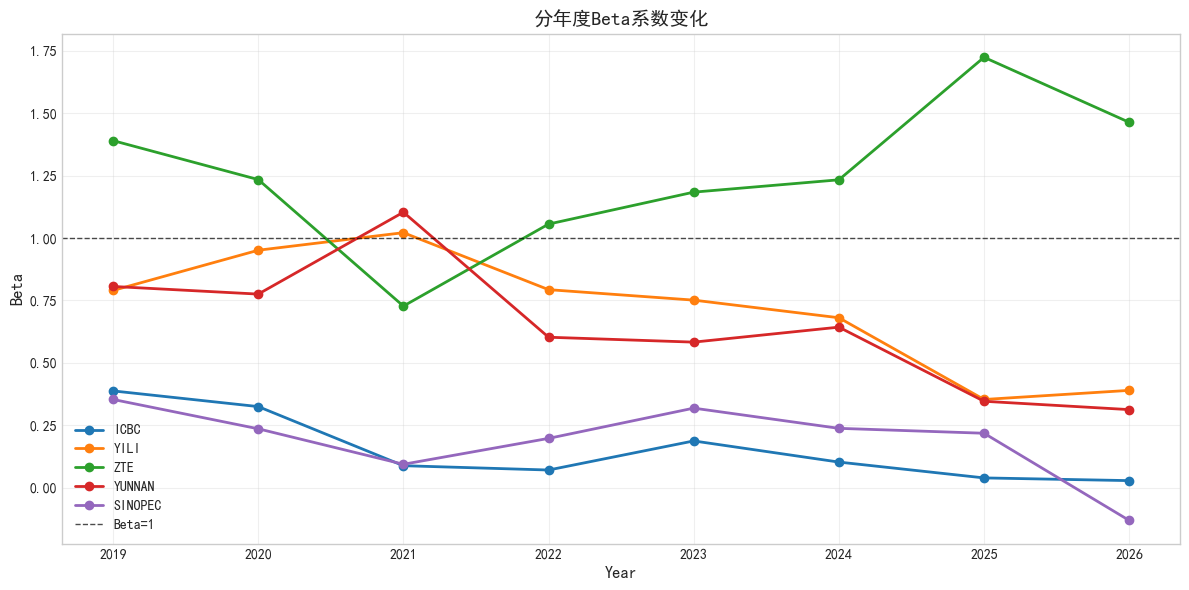

分年度Beta图已保存至 output/Q3_yearly_beta/yearly_beta.png


In [33]:
# 绘制分年度Beta折线图
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, stock in enumerate(stock_names):
    stock_data = yearly_beta_df[yearly_beta_df['Stock'] == stock]
    ax.plot(stock_data['Year'], stock_data['Beta'], marker='o', linewidth=2,
            markersize=6, color=colors[i], label=stock)

ax.axhline(y=1, color='black', linewidth=1, linestyle='--', alpha=0.7, label='Beta=1')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Beta', fontsize=12)
ax.set_title('分年度Beta系数变化', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(years)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_Q3, 'yearly_beta.png'), dpi=150, bbox_inches='tight')
plt.show()

print('分年度Beta图已保存至 output/Q3_yearly_beta/yearly_beta.png')

**结果解读**: 本代码生成分年度Beta系数折线图，展示各股票Beta随时间的变化趋势。黑色虚线Beta=1表示与市场同步波动，可观察2020年COVID-19冲击期间的系统性风险异常变化。

In [34]:
# 保存分年度Beta结果
yearly_beta_df.to_csv(os.path.join(OUTPUT_Q3, 'yearly_beta.csv'), index=False)
yearly_beta_pivot.round(4).to_csv(os.path.join(OUTPUT_Q3, 'yearly_beta_pivot.csv'))

print('分年度Beta结果已保存至 output/Q3_yearly_beta/')

分年度Beta结果已保存至 output/Q3_yearly_beta/


**结果解读**: 本代码保存分年度Beta结果至CSV文件，便于后续分析和报告使用。

## 2.6 滚动Beta系数估计

In [35]:
# 滚动Beta估计
def rolling_beta(stock_excess, market_excess, window=60):
    """
    计算滚动Beta系数
    """
    # 确保数据对齐
    aligned_data = pd.DataFrame({
        'stock': stock_excess,
        'market': market_excess
    }).dropna()
    
    rolling_betas = []
    dates = []
    
    for i in range(window, len(aligned_data) + 1):
        window_data = aligned_data.iloc[i-window:i]
        X = sm.add_constant(window_data['market'])
        y = window_data['stock']
        
        model = sm.OLS(y, X).fit()
        rolling_betas.append(model.params['market'])
        dates.append(aligned_data.index[i-1])
    
    return pd.Series(rolling_betas, index=dates)

# 计算所有股票的滚动Beta
print('开始计算60日滚动Beta，请稍候...')
rolling_betas = {}

for stock in stock_names:
    print(f'  计算 {stock}...')
    rolling_betas[stock] = rolling_beta(excess_returns[stock], excess_returns['CSI300'], window=60)

rolling_beta_df = pd.DataFrame(rolling_betas)
print(f'\n滚动Beta计算完成！')
print(f'数据范围: {rolling_beta_df.index.min()} 至 {rolling_beta_df.index.max()}')
print(f'数据点数: {len(rolling_beta_df)}')

开始计算60日滚动Beta，请稍候...
  计算 ICBC...
  计算 YILI...
  计算 ZTE...
  计算 YUNNAN...
  计算 SINOPEC...

滚动Beta计算完成！
数据范围: 2019-04-04 00:00:00 至 2026-03-25 00:00:00
数据点数: 1680


**结果解读**: 本代码定义了rolling_beta函数，使用60个交易日（约3个月）的滚动窗口估计动态Beta系数。滚动方法可捕捉Beta的时变特征，是分析系统性风险动态演变的标准方法。

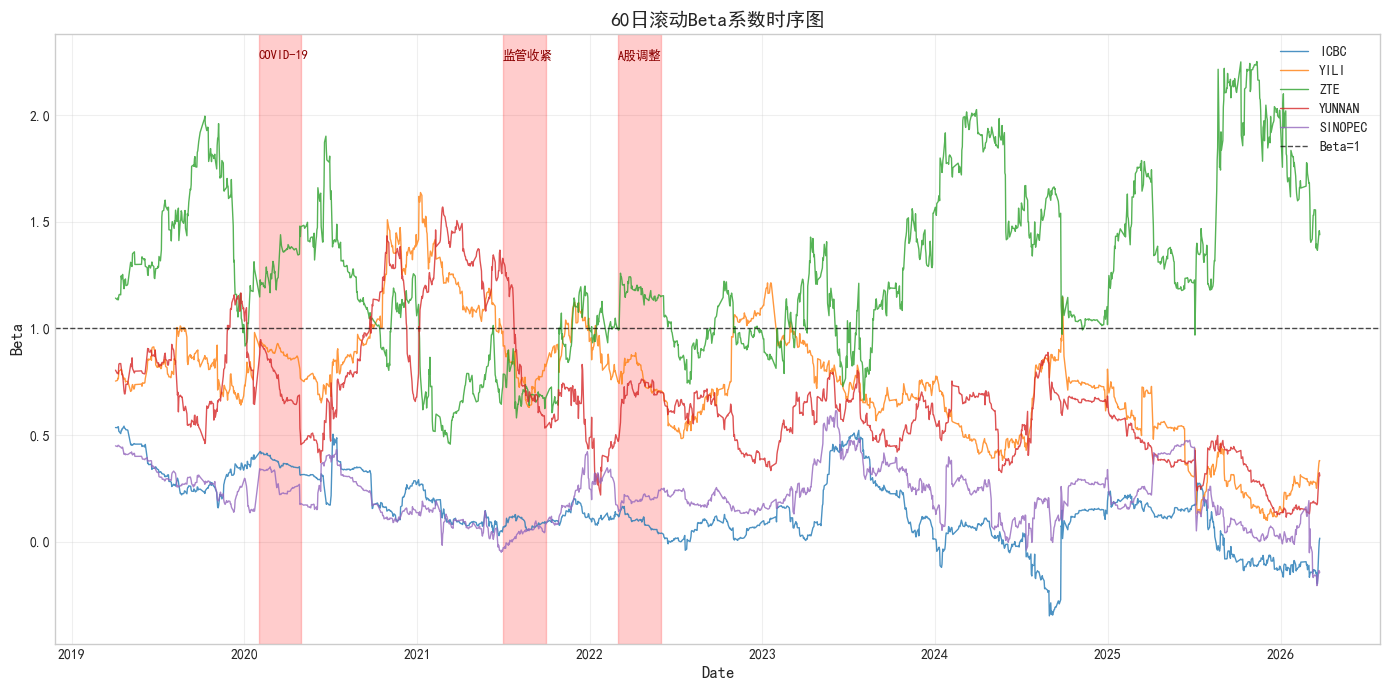

滚动Beta时序图已保存至 output/Q4_rolling_beta/rolling_beta.png


In [36]:
# 绘制滚动Beta时序图
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, stock in enumerate(stock_names):
    ax.plot(rolling_beta_df.index, rolling_beta_df[stock], color=colors[i],
            linewidth=1, alpha=0.8, label=stock)

# 定义市场重大事件
events = {
    'COVID-19': ('2020-02-01', '2020-04-30', 'COVID-19'),
    'Regulatory': ('2021-07-01', '2021-09-30', '监管收紧'),
    'A-Share Crash': ('2022-03-01', '2022-05-31', 'A股调整')
}

# 添加市场事件标注
for event_id, (start, end, label) in events.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.2, color='red')
    ax.annotate(label, xy=(pd.Timestamp(start), ax.get_ylim()[1]*0.95),
                fontsize=9, color='darkred')

ax.axhline(y=1, color='black', linewidth=1, linestyle='--', alpha=0.7, label='Beta=1')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Beta', fontsize=12)
ax.set_title('60日滚动Beta系数时序图', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_Q4, 'rolling_beta.png'), dpi=150, bbox_inches='tight')
plt.show()

print('滚动Beta时序图已保存至 output/Q4_rolling_beta/rolling_beta.png')

**结果解读**: 本代码定义关键市场事件的时间区间，包括COVID-19冲击（2020年2-3月）、监管政策收紧（2021年7月）、A股大幅调整（2022年3月）。这些事件将标注在后续滚动Beta图中。

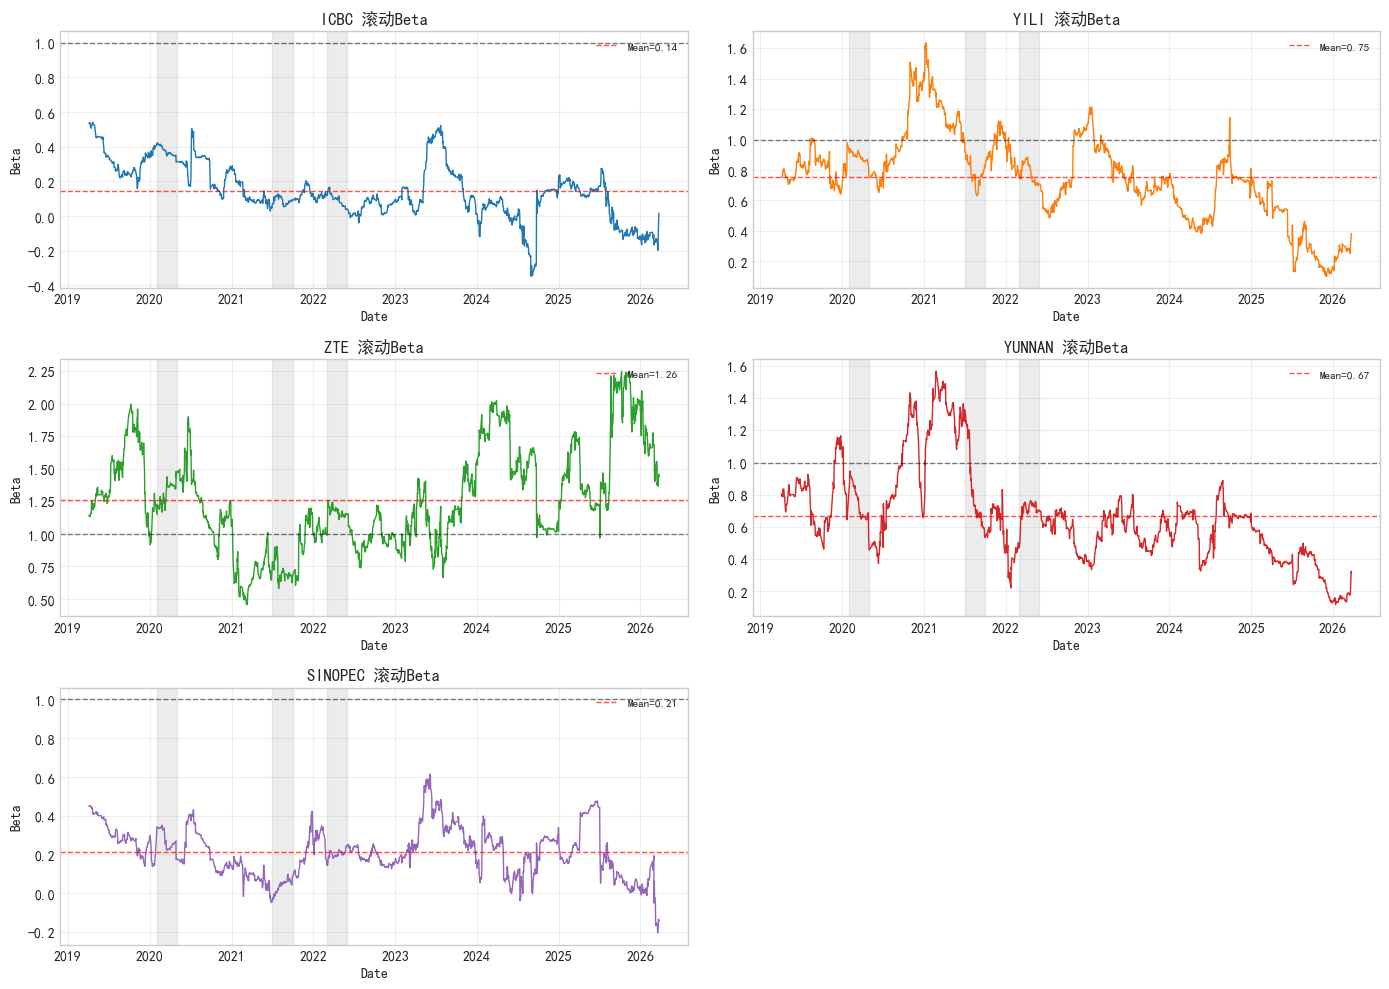

分面滚动Beta图已保存至 output/Q4_rolling_beta/rolling_beta_faceted.png


In [37]:
# 绘制每只股票的滚动Beta（分面图）
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, stock in enumerate(stock_names):
    ax = axes[i]
    ax.plot(rolling_beta_df.index, rolling_beta_df[stock], color=colors[i], linewidth=1)
    ax.axhline(y=1, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.axhline(y=rolling_beta_df[stock].mean(), color='red', linewidth=1,
               linestyle='--', alpha=0.7, label=f'Mean={rolling_beta_df[stock].mean():.2f}')
    
    # 添加市场事件标注
    for event_id, (start, end, label) in events.items():
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color='gray')
    
    ax.set_title(f'{stock} 滚动Beta', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Beta')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

# 隐藏多余的子图
axes[5].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_Q4, 'rolling_beta_faceted.png'), dpi=150, bbox_inches='tight')
plt.show()

print('分面滚动Beta图已保存至 output/Q4_rolling_beta/rolling_beta_faceted.png')

**结果解读**: 本代码生成分面滚动Beta图，每个子图展示一只股票的60日滚动Beta时序。均值线（红色虚线）反映长期平均市场敏感度，灰色阴影标注市场危机时期。

In [38]:
# 计算滚动Beta的统计特征
rolling_stats = pd.DataFrame({
    'Mean': rolling_beta_df.mean(),
    'Std': rolling_beta_df.std(),
    'Min': rolling_beta_df.min(),
    'Max': rolling_beta_df.max(),
    'Range': rolling_beta_df.max() - rolling_beta_df.min()
})

print('='*80)
print('滚动Beta统计特征')
print('='*80)
print(rolling_stats.round(4).to_string())
print('\n注: Range = Max - Min，反映Beta的波动程度')

滚动Beta统计特征
           Mean     Std     Min     Max   Range
ICBC     0.1442  0.1589 -0.3469  0.5420  0.8889
YILI     0.7545  0.2812  0.1003  1.6367  1.5364
ZTE      1.2610  0.3867  0.4574  2.2503  1.7928
YUNNAN   0.6650  0.2858  0.1154  1.5688  1.4534
SINOPEC  0.2129  0.1276 -0.2054  0.6139  0.8193

注: Range = Max - Min，反映Beta的波动程度


**结果解读**: 本代码计算滚动Beta的统计特征：均值反映长期平均市场敏感度；标准差反映Beta的稳定性；Range（最大值-最小值）越大说明Beta越不稳定。

In [39]:
# 保存滚动Beta结果
rolling_beta_df.to_csv(os.path.join(OUTPUT_Q4, 'rolling_beta.csv'))
rolling_stats.round(4).to_csv(os.path.join(OUTPUT_Q4, 'rolling_beta_stats.csv'))

print('滚动Beta结果已保存至 output/Q4_rolling_beta/')

滚动Beta结果已保存至 output/Q4_rolling_beta/


**结果解读**: 本代码保存滚动Beta数据至CSV文件。60个交易日的滚动窗口生成约1680个Beta观察值，可用于进一步分析Beta的分布特征和时序属性。

In [40]:
# 打印任务完成信息
print('='*80)
print('Beta系数估计完成！')
print('='*80)
print('\n生成的文件:')
print('  1. full_sample_beta.csv - 全样本Beta估计结果')
print('  2. residual_diagnostics.csv - 残差诊断结果')
print('  3. yearly_beta.csv - 分年度Beta估计结果')
print('  4. yearly_beta_pivot.csv - 分年度Beta汇总表')
print('  5. rolling_beta.csv - 滚动Beta时序')
print('  6. rolling_beta_stats.csv - 滚动Beta统计特征')
print('\n生成的图形:')
print('  1. yearly_beta.png - 分年度Beta折线图')
print('  2. rolling_beta.png - 滚动Beta时序图')
print('  3. rolling_beta_faceted.png - 分面滚动Beta图')

Beta系数估计完成！

生成的文件:
  1. full_sample_beta.csv - 全样本Beta估计结果
  2. residual_diagnostics.csv - 残差诊断结果
  3. yearly_beta.csv - 分年度Beta估计结果
  4. yearly_beta_pivot.csv - 分年度Beta汇总表
  5. rolling_beta.csv - 滚动Beta时序
  6. rolling_beta_stats.csv - 滚动Beta统计特征

生成的图形:
  1. yearly_beta.png - 分年度Beta折线图
  2. rolling_beta.png - 滚动Beta时序图
  3. rolling_beta_faceted.png - 分面滚动Beta图


**结果解读**: 本代码打印Beta系数估计任务的完成信息，列出生成的数据文件和图形文件清单，包括全样本回归结果、残差诊断结果、分年度Beta、滚动Beta及统计特征。